# 6. Quantum Teleportation

Quantum teleportation transfers an **unknown quantum state** from
one qubit (Alice's) to another (Bob's), using a shared entangled
pair and 2 classical bits — without physically moving the qubit
itself. (No information travels faster than light; Bob still needs
Alice's 2 classical bits to finish the process.)

Qubits used:
- `q0` = the "message" qubit holding the state to teleport (Alice's)
- `q1` = Alice's half of the entangled pair
- `q2` = Bob's half of the entangled pair

## Step 1: Import libraries

In [1]:
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UGate
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_distribution, plot_histogram
import numpy as np

simulator = AerSimulator()

## Step 2: Pick a state to teleport

We use a `U` gate with some arbitrary angles to create a state that
is neither `|0>` nor `|1>` nor a simple 50/50 mix — this shows
teleportation works for ANY state, not just easy ones.

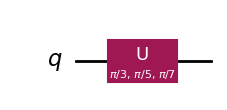

In [2]:
theta, phi, lam = np.pi / 3, np.pi / 5, np.pi / 7
state_prep_gate = UGate(theta, phi, lam)

qc_original = QuantumCircuit(1)
qc_original.append(state_prep_gate, [0])
qc_original.draw("mpl")

Original state (the one we want to teleport): [0.866+0.j    0.405+0.294j]
Original measurement probabilities: {np.str_('0'): np.float64(0.7500000000000001), np.str_('1'): np.float64(0.2499999999999999)}


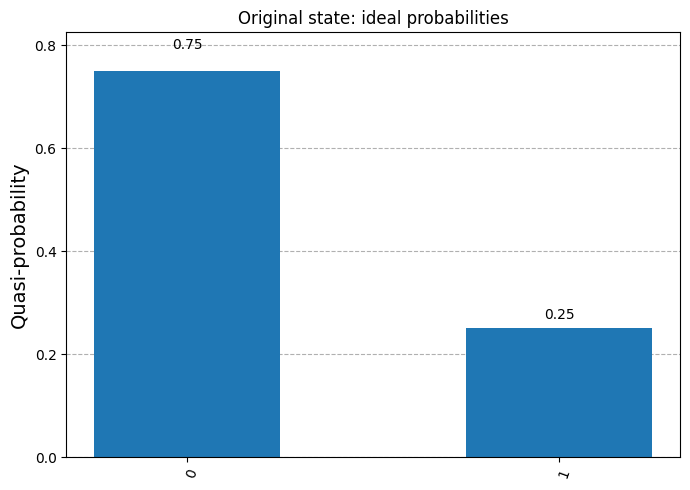

In [3]:
original_state = Statevector(qc_original)
original_probs = original_state.probabilities_dict()
print("Original state (the one we want to teleport):", np.round(original_state.data, 3))
print("Original measurement probabilities:", original_probs)
plot_distribution(original_probs, title="Original state: ideal probabilities")

## Step 3: Build the full teleportation circuit

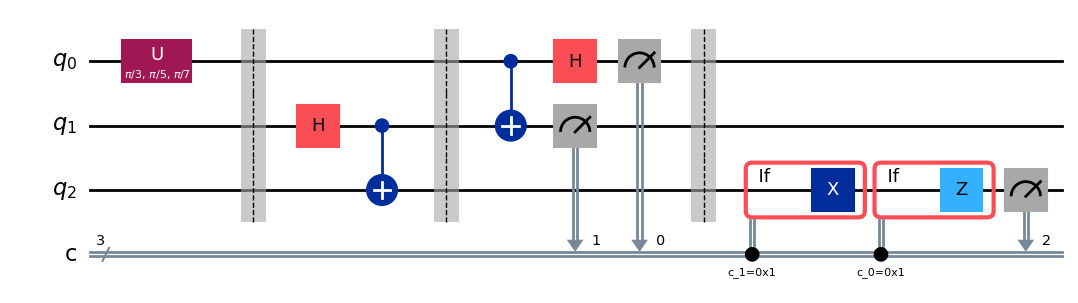

In [4]:
q = QuantumRegister(3, "q")
c = ClassicalRegister(3, "c")
qc = QuantumCircuit(q, c)

# Prepare the state to teleport on q0
qc.append(state_prep_gate, [0])
qc.barrier()

# Create the entangled pair: q1 (Alice) and q2 (Bob)
qc.h(1)
qc.cx(1, 2)
qc.barrier()

# Alice's Bell-basis measurement on q0 and q1
qc.cx(0, 1)
qc.h(0)
qc.measure(0, 0)
qc.measure(1, 1)
qc.barrier()

# Bob applies corrections based on Alice's classical results
with qc.if_test((c[1], 1)):
    qc.x(2)
with qc.if_test((c[0], 1)):
    qc.z(2)

# Measure Bob's qubit to check the teleported state
qc.measure(2, 2)

qc.draw("mpl")

## Step 4: Run it on the Aer simulator

In [5]:
compiled_circuit = transpile(qc, simulator)
counts = simulator.run(compiled_circuit, shots=4096).result().get_counts()
print("Raw counts (bit order is c2 c1 c0):", counts)

Raw counts (bit order is c2 c1 c0): {'101': 302, '110': 254, '111': 259, '011': 745, '100': 233, '010': 772, '000': 778, '001': 753}


## Step 5: Check Bob's qubit only

Bob's final result is classical bit `c2`, which is the FIRST
character in Qiskit's bit-string ordering.

Bob's qubit measured probabilities: {'0': 0.744140625, '1': 0.255859375}
Original state probabilities were: {np.str_('0'): np.float64(0.7500000000000001), np.str_('1'): np.float64(0.2499999999999999)}


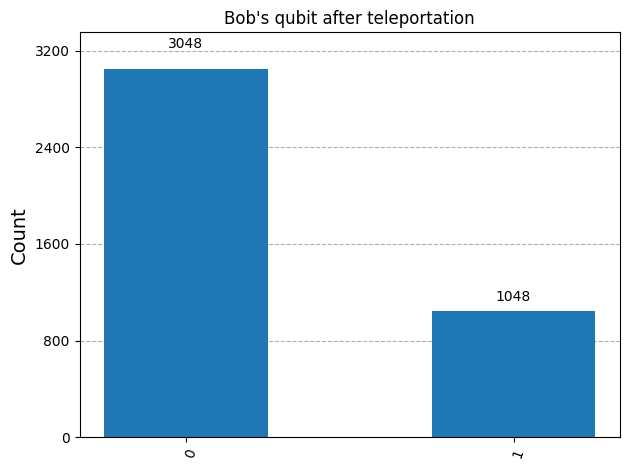

In [6]:
bob_results = {"0": 0, "1": 0}
for bitstring, count in counts.items():
    bob_bit = bitstring[0]
    bob_results[bob_bit] += count

total = sum(bob_results.values())
bob_probs = {k: v / total for k, v in bob_results.items()}

print("Bob's qubit measured probabilities:", bob_probs)
print("Original state probabilities were:", original_probs)

plot_histogram(bob_results, title="Bob's qubit after teleportation")

Compare `bob_probs` above to `original_probs` from Step 2 — they
should match closely. This confirms the exact quantum state was
successfully teleported from Alice's qubit to Bob's qubit.